In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule
from src.utils import inspection

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [ ]:
inspection.inspect_model('resnet101')

In [2]:
model, params = MLFlowRegistry().load_model('models:/crowd_counting/53')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [13]:
params

BaseParams(image_size=None, crop_size=384, label_scaler=1000, aug_factor=None, num_ops=None, backbone='efficientnet-b2', model_class='MAnet', backbone_weights='imagenet', decoder_attention_type=None, trainable_backbone=False, neck_out_channels=None, dropout=None, batch_size=8, lr=0.00065, l2_reg=0.0001, lr_schedule='clipped_exp', monitor_metric='val_nae', loss_function='mse_ssim', grad_accumulation=1, grad_clip=None, scheduler_kwargs={'decay_rate': 0.96, 'min_lr_pct': 0.01}, suggested_params=False, epochs=60, padding_multiple=32, dataset='part_A', train_size=240, unfrozen_blocks=None, optimizer_config={}, extra={})

In [3]:
# import numpy as np
# dummy_input = np.random.randint(0, 256, size=(2, 704, 1056, 3), dtype=np.uint8)
model.predict(torch.randn(2, 3, 704, 1056))

(tensor([1813.0488, 1954.2312], device='cuda:0'),
 tensor([[[0.0025, 0.0045, 0.0061,  ..., 0.0059, 0.0048, 0.0029],
          [0.0034, 0.0072, 0.0088,  ..., 0.0086, 0.0072, 0.0045],
          [0.0048, 0.0094, 0.0122,  ..., 0.0097, 0.0078, 0.0051],
          ...,
          [0.0006, 0.0005, 0.0005,  ..., 0.0017, 0.0013, 0.0013],
          [0.0004, 0.0004, 0.0005,  ..., 0.0012, 0.0011, 0.0010],
          [0.0006, 0.0006, 0.0005,  ..., 0.0010, 0.0008, 0.0007]],
 
         [[0.0018, 0.0029, 0.0040,  ..., 0.0033, 0.0028, 0.0018],
          [0.0025, 0.0047, 0.0060,  ..., 0.0056, 0.0048, 0.0030],
          [0.0032, 0.0064, 0.0082,  ..., 0.0076, 0.0064, 0.0041],
          ...,
          [0.0023, 0.0034, 0.0037,  ..., 0.0013, 0.0010, 0.0009],
          [0.0018, 0.0026, 0.0028,  ..., 0.0009, 0.0007, 0.0007],
          [0.0011, 0.0017, 0.0017,  ..., 0.0007, 0.0006, 0.0006]]],
        device='cuda:0'))

In [3]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage='test')

182 images found in /teamspace/lightning_storage/datasets/ShanghaiTech/part_A/test_data/images
182 h5 files found in /teamspace/lightning_storage/datasets/ShanghaiTech/part_A/test_data/ground-truth-h5


In [4]:
model.evaluate(datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpo

Output()

dict_items([('val_mae', 8369.205078125), ('val_nae', 30.539100646972656), ('val_rmse', 9111.7021484375), ('epoch_idx', 0.0), ('val_loss', 0.5851264595985413)])

In [ ]:
# from src.models.ensembled_model import EnsembledCrowdCounter

# model = mlflow.pyfunc.load_model('models:/crowd_counting/53')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [5]:
sample, target, count = helpers.get_sample_from_dm(datamodule, index=6)
sample.shape

torch.Size([1, 3, 704, 1024])

In [3]:
from torchvision.transforms import v2
from PIL import Image

from src.data import transform_sample
original_image = Image.open('/teamspace/studios/this_studio/workspace/crowd_counting/testing_images/input/hama_protests.jpg').convert('RGB')
image = transform_sample.preprocess(original_image, params)

In [7]:
result  = model.predict(sample)
result = (float(result[0][0]), result[1])
result

(1592.405517578125,
 tensor([[[0.0006, 0.0005, 0.0004,  ..., 0.0010, 0.0009, 0.0007],
          [0.0005, 0.0004, 0.0002,  ..., 0.0012, 0.0011, 0.0010],
          [0.0004, 0.0003, 0.0002,  ..., 0.0015, 0.0014, 0.0012],
          ...,
          [0.0004, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0004],
          [0.0005, 0.0003, 0.0002,  ..., 0.0002, 0.0002, 0.0004],
          [0.0005, 0.0004, 0.0003,  ..., 0.0003, 0.0003, 0.0004]]],
        device='cuda:0'))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


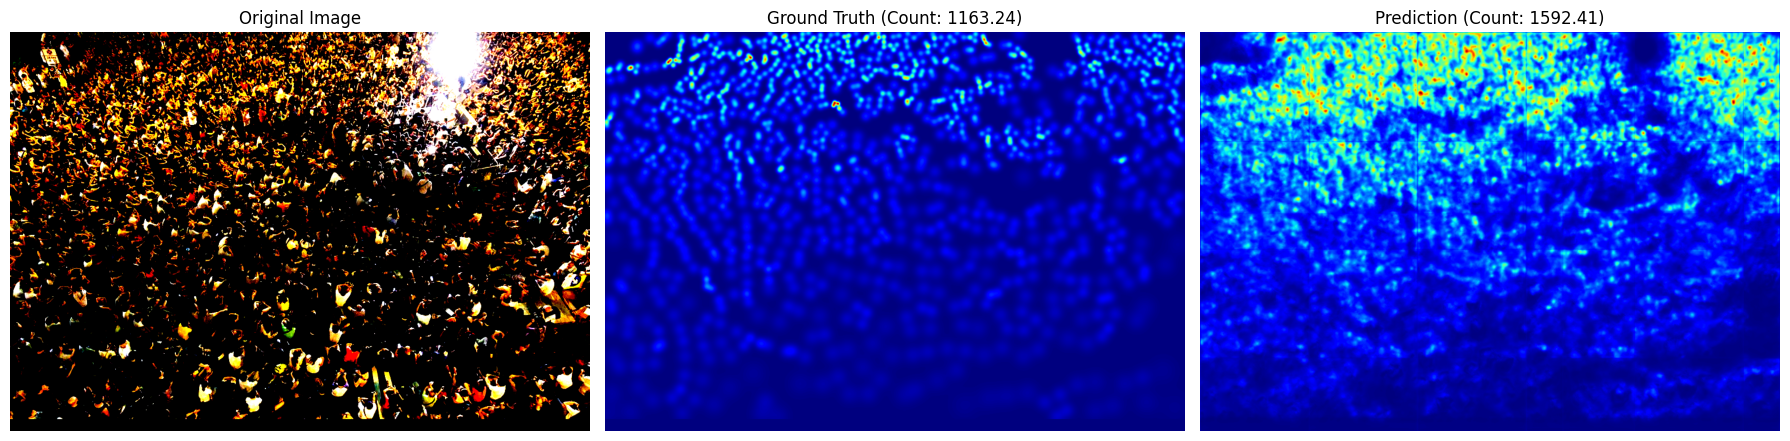

In [9]:
vis.visualize_sample(sample, target=(count, target), pred=result, cmap='jet')

In [ ]:
vis.visualize_model_graph(model.model, sample=sample)